In [610]:
# importing the required library
import pandas as pd
import numpy as np


In [611]:
# loading dataset
data=pd.read_csv("pima_indians_diabetes.csv")
data.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
557,8,110,76,0,0,27.8,0.237,58,0
478,8,126,74,38,75,25.9,0.162,39,0
519,6,129,90,7,326,19.6,0.582,60,0
451,2,134,70,0,0,28.9,0.542,23,1
59,0,105,64,41,142,41.5,0.173,22,0
210,2,81,60,22,0,27.7,0.290,25,0
762,9,89,62,0,0,22.5,0.142,33,0
180,6,87,80,0,0,23.2,0.084,32,0
574,1,143,86,30,330,30.1,0.892,23,0
418,1,83,68,0,0,18.2,0.624,27,0


Section 1 — Data Understanding (Q1–Q8)

Q1. What is the shape of the dataset — how many rows and columns does it have?

In [612]:
data.shape

(768, 9)

it have 768 rows and 9 columns

Q2. What are all the column names and what does each column medically represent in plain English?


In [613]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetespedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Each columns represent the following medicall condition:-

Pregnancies = Number of times pregnant

Glucose = Plasma glucose concentration a 2 hours in an oral glucose tolerance test

BloodPressure = Diastolic blood pressure (mm Hg)

SkinThickness =  physical measurement used to estimate body fat percentage and overall nutritional status(mm)

Insulin = 2-Hour serum insulin (mu U/ml)

BMI = Body mass index (weight in kg/(height in m)^2)

DiabetesPedigreeFunction = score that estimates a person's risk of developing diabetes based on their genetic family history

Age = Age (years)

Outcome = Class variable (0 or 1) 268 of 768 are 1, the others are 0

Q3. What are the data types of each column — are they appropriate for analysis?


In [614]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetespedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


all the columns have numerical data so they are appropriate for analysis

Q4. What are the basic statistics — mean, median, min, max, and standard deviation of every column?


In [615]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Q5. How many patients are diabetic (Outcome=1) vs non-diabetic (Outcome=0) — what is the percentage of each?

In [616]:
data['Outcome'].value_counts()


Outcome
0    500
1    268
Name: count, dtype: int64

diabetic patients= 268 and Non diabetic patients=500

In [617]:
# to see the data into percentage 
# normalize = Ture means (value count/total number of row)
(data['Outcome'].value_counts(normalize=True)*100).round(2).map("{:.2f}%".format)

Outcome
0    65.10%
1    34.90%
Name: proportion, dtype: object

65.10% are diabetic patients and 34.90% are diabetic patients

Q6. Are there any NaN missing values in the dataset?

In [618]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetespedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

No, there are no missing values in any column.

Q7. Are there any duplicate rows in the dataset?


In [619]:
data.duplicated().sum()

np.int64(0)

No, there are no any duplicate data

Q8. What is the age range of patients — what is the youngest, oldest, and average age?

In [620]:
youngest_patient_age=data['Age'].min()
oldest_patient_age=data['Age'].max()
average_age=data['Age'].mean().round(2)
print(f"Youngest Patient Age = {youngest_patient_age}, Oldest Patient Age = {oldest_patient_age}, Average Patient Age = {average_age}")

Youngest Patient Age = 21, Oldest Patient Age = 81, Average Patient Age = 33.24


Section 2 — Data Cleaning (Q9–Q16)

Q9. Count how many zero values exist in each column — which columns have medically impossible zeros where 0 cannot exist in real life?

In [621]:
(data==0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetespedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Glucose, BloodPressure, SkinThickness, Insulin, BMI columns have medically impossible zero values where O can't exist in real life:-


Q10. Replace all medically impossible zero values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI with NaN — keep Pregnancies zeros as they are valid


In [622]:
data['Glucose']=data['Glucose'].replace(0,np.nan)
data['BloodPressure']=data['BloodPressure'].replace(0,np.nan)
data['SkinThickness']=data['SkinThickness'].replace(0,np.nan)
data['Insulin']=data['Insulin'].replace(0,np.nan)
data['BMI']=data['BMI'].replace(0,np.nan)

Q11. After replacing zeros with NaN — how many actual missing values does each column now have? Show as both count and percentage.

In [623]:
data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetespedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [624]:
missing_count=data.isnull().sum()
missing_percent=(data.isnull().sum()/len(data)*100).round(2)
missing_data = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Pecentage": missing_percent.map("{:.2f}%".format)
})
print(missing_data)

                          Missing Count Missing Pecentage
Pregnancies                           0             0.00%
Glucose                               5             0.65%
BloodPressure                        35             4.56%
SkinThickness                       227            29.56%
Insulin                             374            48.70%
BMI                                  11             1.43%
DiabetespedigreeFunction              0             0.00%
Age                                   0             0.00%
Outcome                               0             0.00%


Q12. Fill all missing values using median imputation — why is median better than mean for this medical data?

In [625]:
data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetespedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [626]:
Glucose_median=data['Glucose'].median()
data['Glucose']=data['Glucose'].replace(np.nan,Glucose_median)

BloodPressure_median=data['BloodPressure'].median()
data['BloodPressure']=data['BloodPressure'].replace(np.nan,BloodPressure_median)

SkinThickness_median=data['SkinThickness'].median()
data['SkinThickness']=data['SkinThickness'].replace(np.nan,SkinThickness_median)

Insulin_median=data['Insulin'].median()
data['Insulin']=data['Insulin'].replace(np.nan,Insulin_median)

BMI_median=data['BMI'].median()
data['BMI']=data['BMI'].replace(np.nan,BMI_median)


median is better then mean in medical data because median is not affected by the extreme outliers but the mean values are affected due to the extreme outliers

In [627]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetespedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Q13. Detect outliers in the Insulin column using the IQR method — how many outlier values exist?

In [628]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
q1 = data['Insulin'].quantile(0.25)
q3 = data['Insulin'].quantile(0.75)

# calculate the IQR (Inter Quantile Range)
IQR = q3-q1

# Define outlier boundaries
lower_bound = q1-1.5*IQR
upper_bound = q3+1.5*IQR

# filtering the rows containing outliers
outliers = data[(data['Insulin']<lower_bound) | (data['Insulin']>upper_bound)]
print(len(outliers))


346


346 outliers values exist in Insulin column


Q14. Check for patients with Pregnancies greater than 15 — how many are there and are they diabetic?

In [629]:
data[data['Pregnancies']>15]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
159,17,163.0,72.0,41.0,114.0,40.9,0.817,47,1


there is only one patient with pragnancies count greaten then 15 and she is diabetic

Q15. Create a new column called BMI_Category using these medical thresholds — Underweight below 18.5, Normal 18.5 to 24.9, Overweight 25 to 29.9, Obese 30 and above. How many patients fall in each category?

In [630]:
# underweight=data[data['BMI']<18.5]
# normal=data[(data['BMI']>18.5) | (data['BMI']<24.9)]
# overweight=data[(data['BMI']>25) | (data['BMI']<29.9)]
# obese=data[(data['BMI']>=30)]

# dataFrame.loc[condition, 'Column_Name'] = 'Value'
data.loc[data['BMI']<18.5,'BMI_Category'] = 'underweight'
data.loc[((data['BMI']>=18.5)  & (data['BMI']<=24.9)),'BMI_Category'] = 'normal'
data.loc[((data['BMI']>=25) & (data['BMI']<=29.9)),'BMI_Category'] = 'overweight'
data.loc[(data['BMI']>=30),'BMI_Category'] = 'obese'
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome,BMI_Category
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,obese
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,overweight
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,normal
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,overweight
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,obese
...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0,obese
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0,obese
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0,overweight
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1,obese


In [631]:
data['BMI_Category'].value_counts()

BMI_Category
obese          483
overweight     179
normal         102
underweight      4
Name: count, dtype: int64

Q16. Create a new column called Age_Group — Young for ages 21 to 30, Middle for 31 to 45, Senior for 46 and above. How many diabetic patients are in each group?

In [632]:
data.loc[((data['Age']>=21) & (data['Age']<=30)),'Age_Group'] = 'Young'
data.loc[((data['Age']>=31) & (data['Age']<=45)),'Age_Group'] = 'Middle'
data.loc[(data['Age']>=46),'Age_Group'] = 'Senior'

In [633]:
data.groupby('Age_Group')['Outcome'].value_counts()

Age_Group  Outcome
Middle     1          120
           0          113
Senior     0           60
           1           58
Young      0          327
           1           90
Name: count, dtype: int64

so 120 middle aged patient, 58 Senior aged patiend and 90 young aged patient have diabetic

In [634]:
# another way to do the same
pd.crosstab(data['Age_Group'],data['Outcome'])

Outcome,0,1
Age_Group,,
Middle,113,120
Senior,60,58
Young,327,90


Section 3 — Data Manipulation (Q17–Q24)

Q17. Compare the mean values of ALL features between diabetic and non-diabetic patients — which features show the biggest difference?

In [635]:
data.groupby('Outcome').mean(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164


the Insulin shows the highest difference of about 36 then Glucose shows highest about 31

Q18. Filter the dataset to show only high-risk patients who have Glucose above 140 AND BMI above 30 — what percentage of these patients are actually diabetic?

In [636]:
high_risk_patients=data[(data['Glucose']>140) & (data['BMI']>30)]

print(len(high_risk_patients),"total high risk patient") # total high risk patient

print(((high_risk_patients['Outcome']==1).sum()),"total high risk patient with diabetic") # total high risk patient with diabetic

result = (((high_risk_patients['Outcome']==1).sum()) / (len(high_risk_patients)) * 100).round(2)
print(f"{result}% of high risk patient are actually diabetic")

148 total high risk patient
112 total high risk patient with diabetic
75.68% of high risk patient are actually diabetic


Q19. Calculate the diabetes rate for each Age Group — which age group has the highest diabetes percentage?

In [637]:
data['Age_Group'].value_counts()

Age_Group
Young     417
Middle    233
Senior    118
Name: count, dtype: int64

In [638]:
# for Young Age Group 
young_diabetic = len(data[(data['Age_Group']=='Young') & (data['Outcome']==1)]) # total young diabetic 
total_young = len(data[data['Age_Group']=='Young']) # total young age group
print(f"Young diabetic % = {((young_diabetic / total_young) * 100):.2f}")

# for Middle Age Group
middle_diabetic = len(data[(data['Age_Group']=='Middle') & (data['Outcome']==1)]) 
total_middle = len(data[data['Age_Group']=='Middle'])
print(f"Middle diabetic % = {((middle_diabetic/total_middle)*100):.2f}")

# for Senior Age Group
senior_diabetic = len(data[(data['Age_Group']=='Senior') & (data['Outcome']==1)]) 
total_senior = len(data[data['Age_Group']=='Senior']) 
print(f"Senior diabetic % = {((senior_diabetic/total_senior)*100):.2f}")

Young diabetic % = 21.58
Middle diabetic % = 51.50
Senior diabetic % = 49.15


middle age group have the highest diabetic percentage i.e 51.5%

Q20. Calculate the diabetes rate by BMI Category — does Obese always mean higher diabetes risk compared to Normal weight?

In [639]:
data['BMI_Category'].value_counts()

BMI_Category
obese          483
overweight     179
normal         102
underweight      4
Name: count, dtype: int64

In [640]:
# for obese BMI Category
obese_diabetic=len(data[(data['BMI_Category']=='obese') & (data['Outcome']==1)])
total_obese=len(data[data['BMI_Category']=='obese'])
obese_diabetic_rate=(obese_diabetic/total_obese)*100
print(f" obese diabetic rate = {(obese_diabetic_rate):.2f}%")

# for overweight BMI Category
overweight_diabetic=len(data[(data['BMI_Category']=='overweight') & (data['Outcome']==1)])
total_overweight=len(data[data['BMI_Category']=='overweight'])
overweight_diabetic_rate=(overweight_diabetic/total_overweight)*100
print(f" over weight diabetic rate = {(overweight_diabetic_rate):.2f}%")

# for Normal BMI Category
normal_diabetic=len(data[(data['BMI_Category']=='normal') & (data['Outcome']==1)])
total_normal=len(data[data['BMI_Category']=='normal'])
normal_diabetic_rate=(normal_diabetic/total_normal)*100
print(f" normal diabetic rate = {(normal_diabetic_rate):.2f}%")

#for underweight BMI Category
underweight_diabetic=len(data[(data['BMI_Category']=='underweight') & (data['Outcome']==1)])
total_underweight=len(data[data['BMI_Category']=='underweight'])
underweight_diabetic_rate=(underweight_diabetic/total_underweight)*100
print(f" under weight diabetic rate = {(underweight_diabetic_rate):.2f}%")

 obese diabetic rate = 45.76%
 over weight diabetic rate = 22.35%
 normal diabetic rate = 6.86%
 under weight diabetic rate = 0.00%


Yes, Obese always mean higher diabetes risk compared to Normal weight.

Q21. Create a Glucose_Risk column using real medical thresholds — Normal below 100, Prediabetic 100 to 125, Diabetic Range 126 and above. What percentage of patients in each risk level are actually diabetic?


In [641]:
# dataFrame.loc[condition, 'Column_Name'] = 'Value'
data.loc[(data['Glucose']<100),'Glucose_Risk'] = 'Normal'
data.loc[((data['Glucose']>=100) & (data['Glucose']<=125)),'Glucose_Risk'] = 'Prediabetic'
data.loc[(data['Glucose']>=126),'Glucose_Risk'] = 'Diabetic'

data['Glucose_Risk'].value_counts()

Glucose_Risk
Diabetic       297
Prediabetic    279
Normal         192
Name: count, dtype: int64

In [642]:
Diabetic_rate=(len(data[(data['Glucose_Risk']=='Diabetic') & (data['Outcome']==1)]) / len(data[data['Glucose_Risk']=='Diabetic']))*100
print(f"{(Diabetic_rate):.2f}% of patient in Diabetic Risk level are actually diabetic")

Prediabetic_rate=(len(data[(data['Glucose_Risk']=='Prediabetic') & (data['Outcome']==1)]) / len(data[data['Glucose_Risk']=='Prediabetic']))*100
print(f"{(Prediabetic_rate):.2f}% of patient in Prediabetic Risk level are actually diabetic")

Normal_rate=(len(data[(data['Glucose_Risk']=='Normal') & (data['Outcome']==1)]) / len(data[data['Glucose_Risk']=='Normal']))*100
print(f"{(Normal_rate):.2f}% of patient in Normal Risk level are actually diabetic")

59.26% of patient in Diabetic Risk level are actually diabetic
27.96% of patient in Prediabetic Risk level are actually diabetic
7.29% of patient in Normal Risk level are actually diabetic


Q22. Find the top 10 patients with the highest Glucose levels — show their Glucose, BMI, Age, and Outcome. Are they all diabetic?

In [643]:
data.sort_values(by='Glucose', ascending=False).head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Risk
661,1,199.0,76.0,43.0,125.0,42.9,1.394,22,1,obese,Young,Diabetic
561,0,198.0,66.0,32.0,274.0,41.3,0.502,28,1,obese,Young,Diabetic
228,4,197.0,70.0,39.0,744.0,36.7,2.329,31,0,obese,Middle,Diabetic
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1,obese,Senior,Diabetic
579,2,197.0,70.0,99.0,125.0,34.7,0.575,62,1,obese,Senior,Diabetic
408,8,197.0,74.0,29.0,125.0,25.9,1.191,39,1,overweight,Middle,Diabetic
359,1,196.0,76.0,36.0,249.0,36.5,0.875,29,1,obese,Young,Diabetic
22,7,196.0,90.0,29.0,125.0,39.8,0.451,41,1,obese,Middle,Diabetic
206,8,196.0,76.0,29.0,280.0,37.5,0.605,57,1,obese,Senior,Diabetic
675,6,195.0,70.0,29.0,125.0,30.9,0.328,31,1,obese,Middle,Diabetic


In top 10 patitents with the highest Glucose Level only one patient is not diabetic

Q23. Calculate the correlation of every feature with Outcome — rank them from strongest to weakest predictor of diabetes.

In [644]:
# data.corr(numeric_only=True) -> this code gives the matrix of all columns vs all columns
# data.corr(numeric_only=Ture)['Outcome']  -> this code gives matrix of all columns vs Outcome column
data.corr(numeric_only=True)['Outcome'].drop('Outcome').sort_values(ascending=False)

Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetespedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64

Q24. What is the average number of pregnancies for diabetic vs non-diabetic patients — does having more pregnancies increase diabetes risk?

In [645]:
data.groupby('Outcome')['Pregnancies'].mean().round(2)

Outcome
0    3.30
1    4.87
Name: Pregnancies, dtype: float64

Non-diabetic average number of pregnancies = 3.30

diabetic average number of pregnancies = 4.87 

it clearly shows that patient with higher number of pregnencies are diabetic

Section 4 — Visualization with Seaborn (Q25–Q35)

Q25. Plot a countplot showing the number of diabetic vs non-diabetic patients — add percentage labels on each bar.

In [646]:
import seaborn as sns
import matplotlib.pyplot as plt



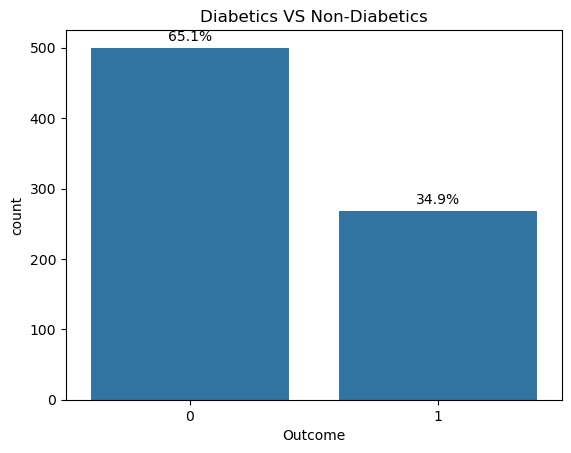

In [647]:
sns.countplot(data=data, x='Outcome')
plt.title("Diabetics VS Non-Diabetics")

percentages = data['Outcome'].value_counts(normalize=True) * 100

# 3. Format them as strings with a '%' sign
pct_labels = [f'{p:.1f}%' for p in percentages]

# 4. Put them on the bars
plt.bar_label(plt.gca().containers[0], labels=pct_labels, padding=3)
plt.show()

Q26. Plot histograms for all 8 numerical features in a single figure — what is the distribution shape of each? Is Insulin skewed?

In [648]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetespedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
 9   BMI_Category              768 non-null    object 
 10  Age_Group                 768 non-null    object 
 11  Glucose_Risk              768 non-null    object 
dtypes: float64(6), int64(3), object(3)
memory usage: 72.1+ KB


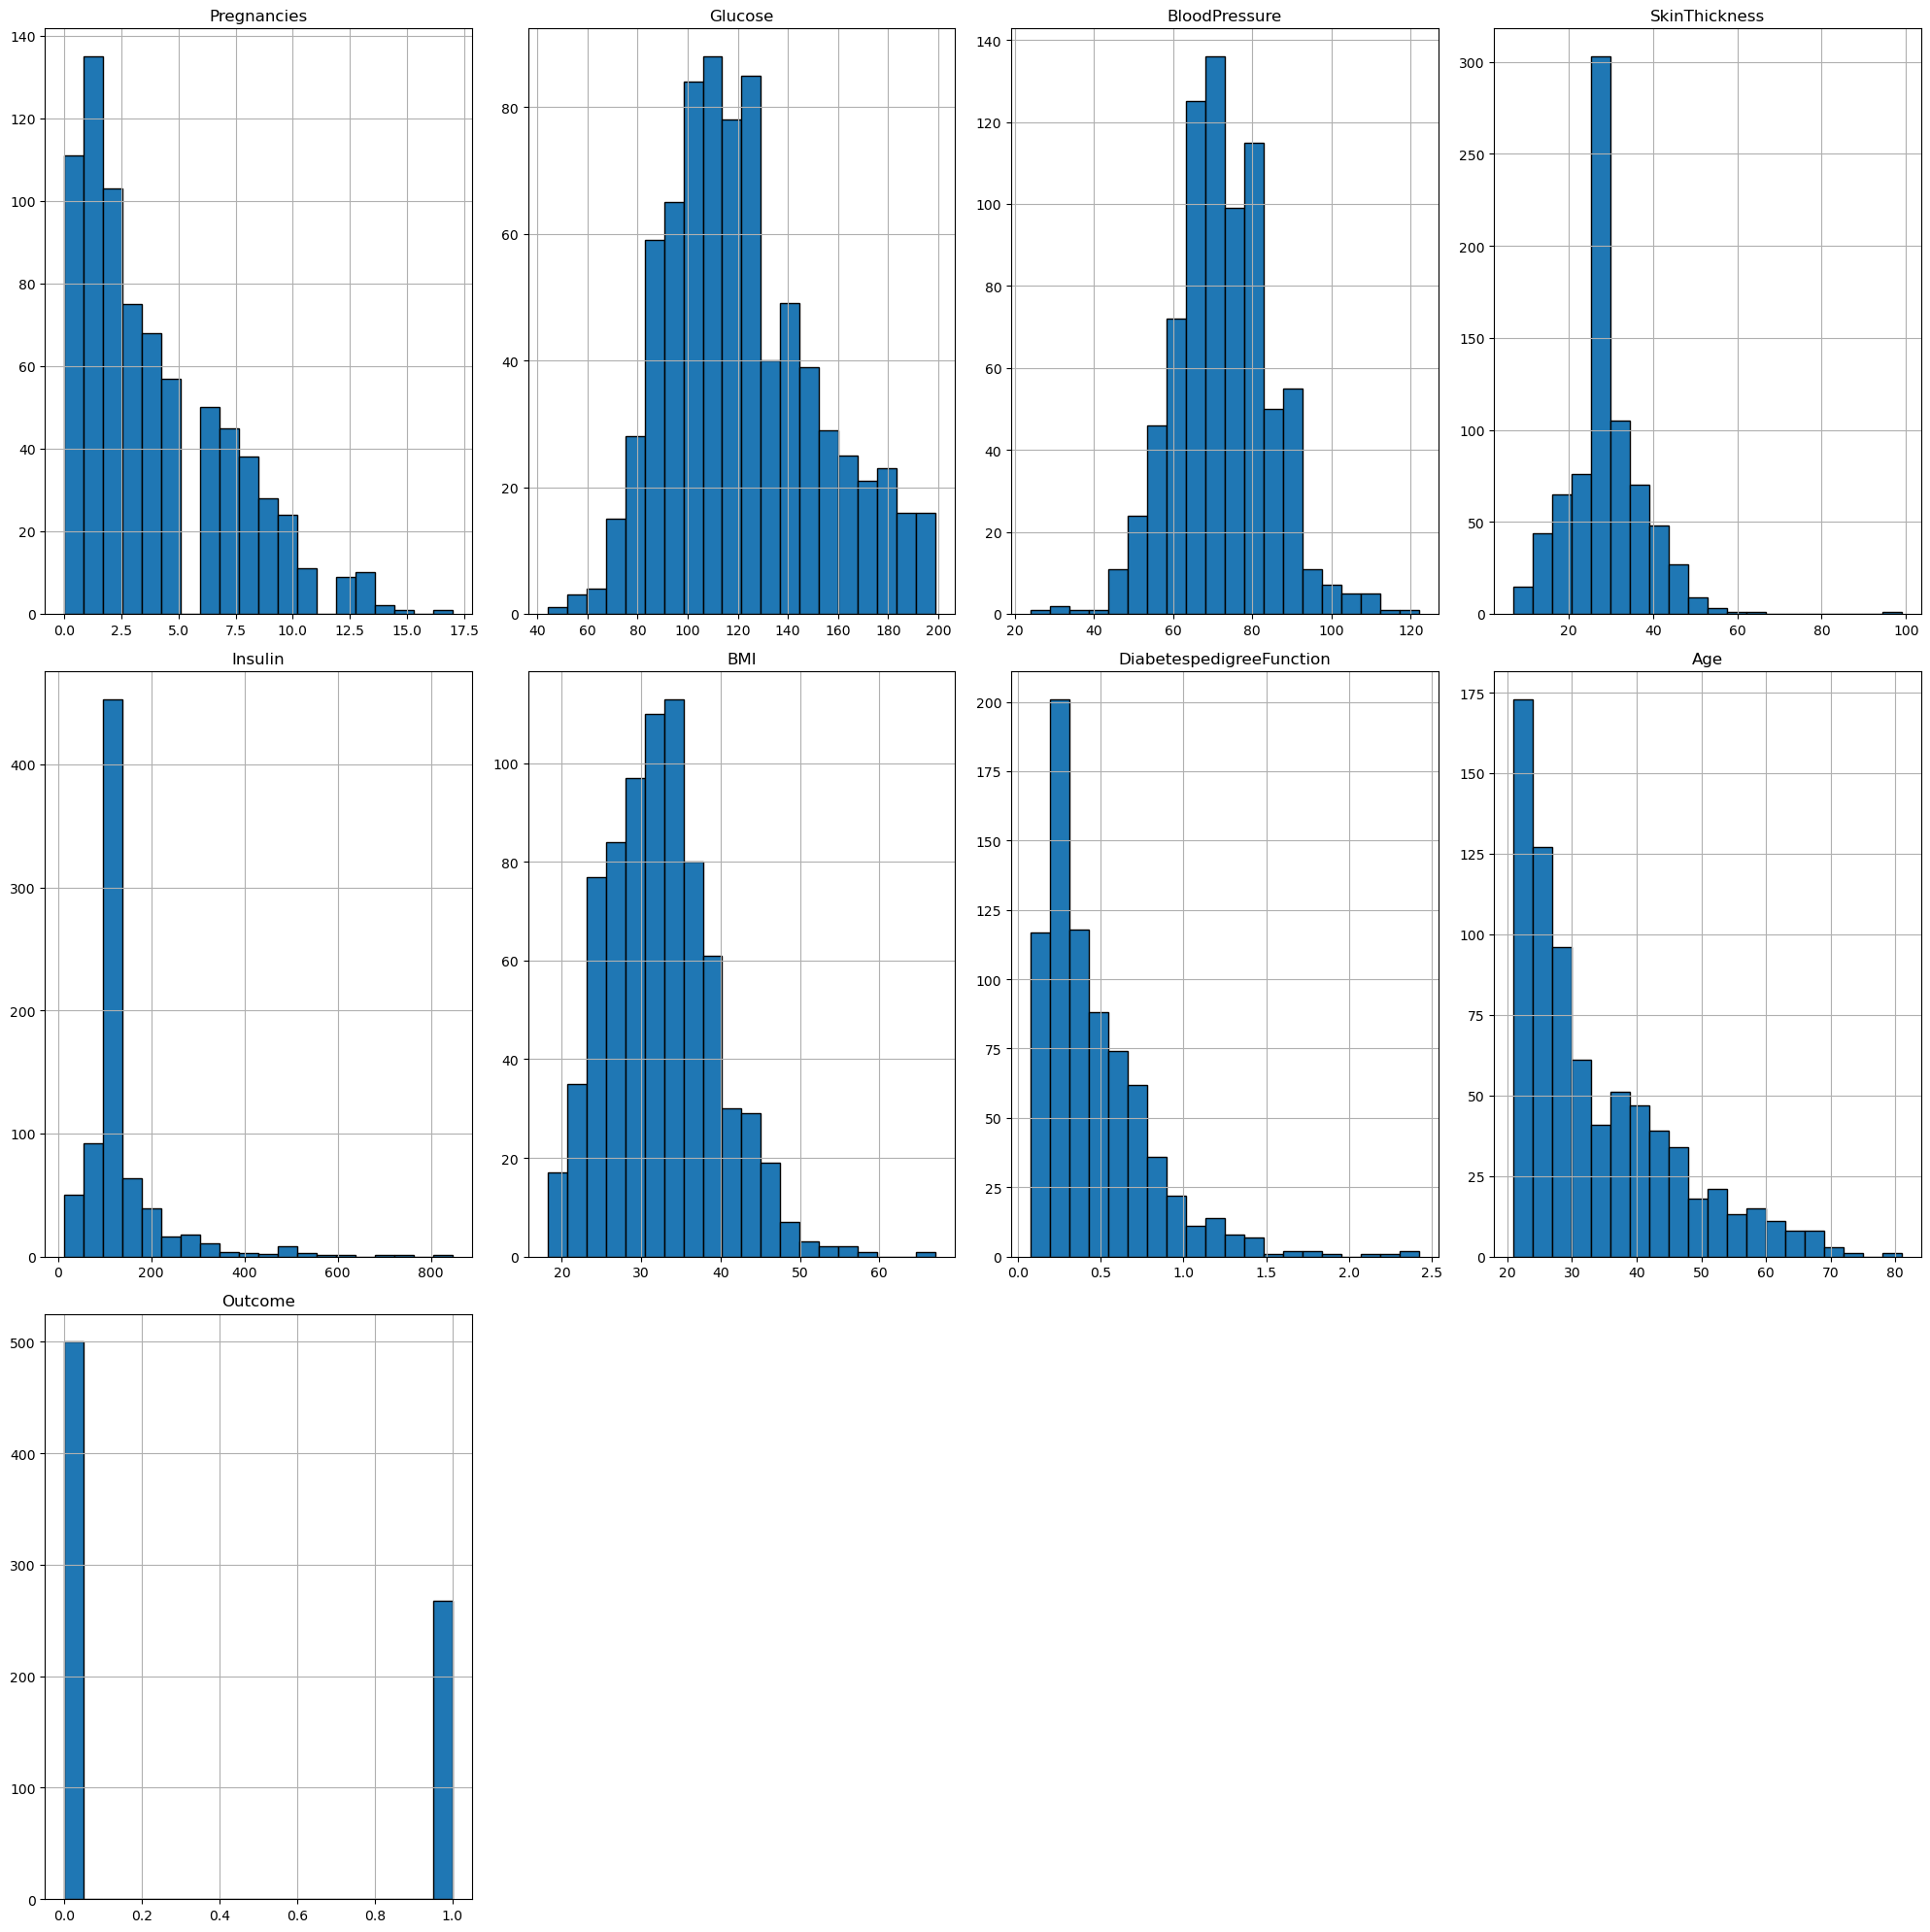

In [649]:
numerical_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                      'Insulin', 'BMI', 'DiabetespedigreeFunction', 'Age', 'Outcome']

# Plot all histograms in a 2x4 grid layout
data[numerical_features].hist(bins=20, figsize=(20, 20), layout=(3, 4), edgecolor='black')

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()

Q27. Plot a correlation heatmap of all features with annotation — which feature is most correlated with Outcome?

In [650]:
data.corr(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetespedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


<Axes: >

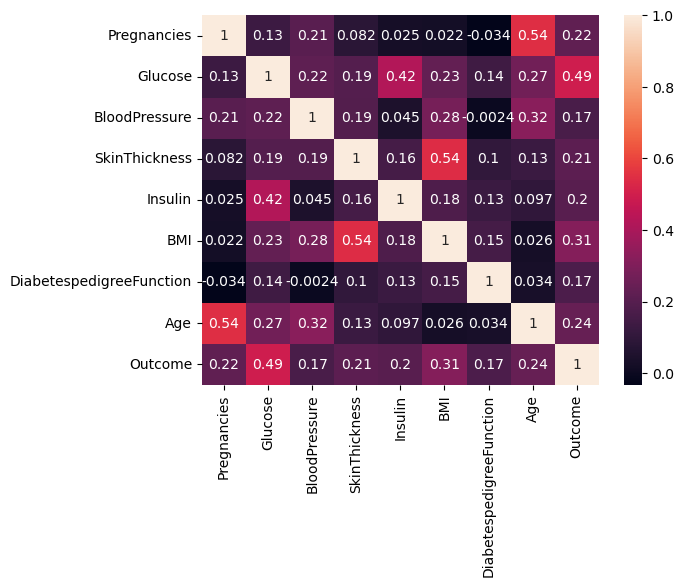

In [651]:
sns.heatmap(data.corr(numeric_only=True),annot=True)

so glucose feature is most correlated with the outcome. i,e in outcome row which column have the highest value

Strongest Predictor Glucose =0.492782	

Q28. Plot boxplots for Glucose, BMI, Age, Insulin, and BloodPressure grouped by Outcome — which feature shows the clearest separation between diabetic and non-diabetic patients?

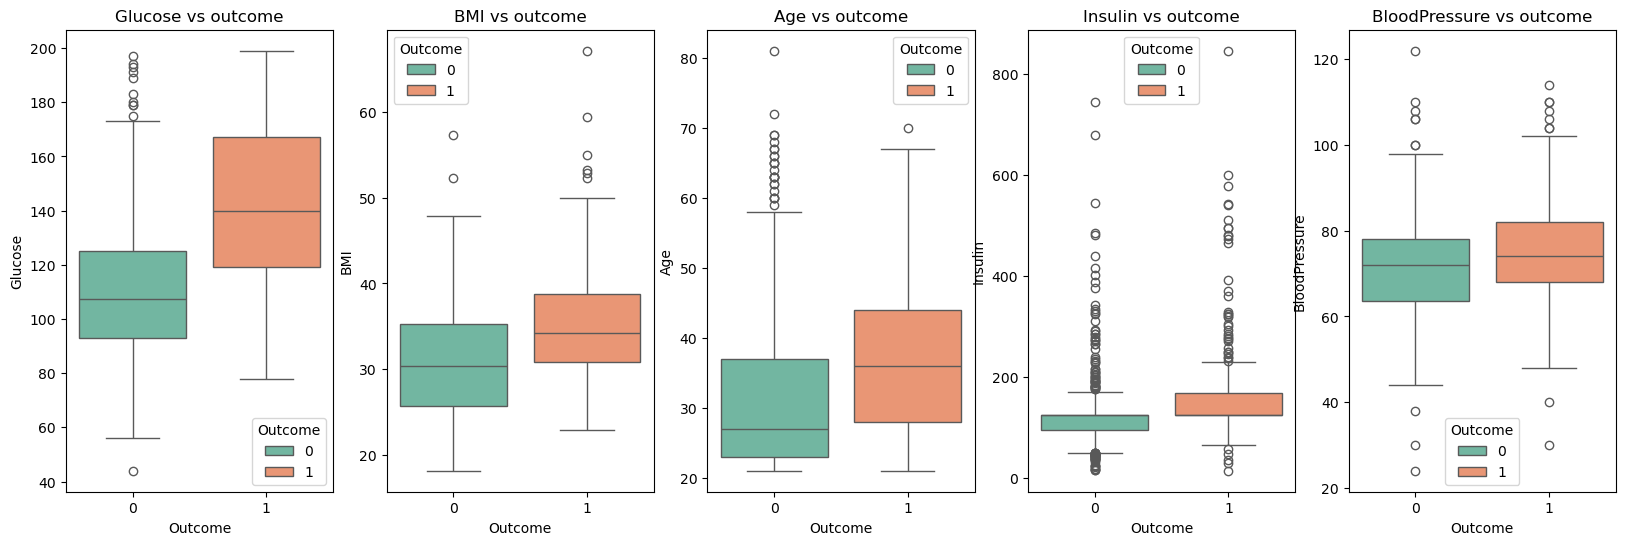

In [652]:
# 1. Define the 5 features requested by the question
features = ['Glucose', 'BMI', 'Age', 'Insulin', 'BloodPressure']

# 2. Set up a grid with 1 row and 5 columns
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 6))

for i, col in enumerate(features):
    sns.boxplot(data=data,x='Outcome', y=col, ax=axes[i],palette='Set2', hue='Outcome')
    axes[i].set_title(f"{col} vs outcome")

plt.show()

Glucose vs outcome shows the clean seperation between diabetic and non-diabetic. 

To see this seperation, look as the figure of Glucose vs outcome. in this figure look at the green box in which the top edge is at 125. but in the orange box top edge is at around 165 which is way then 125 of green box. similarly compare all the edges of the two boxes. None of the same edges in both box are nearly equal. so their is clean seperation between diabetic and non-diabetic.


Q29. Plot a violin plot of Glucose split by Outcome — how does the glucose distribution shape differ between the two groups?

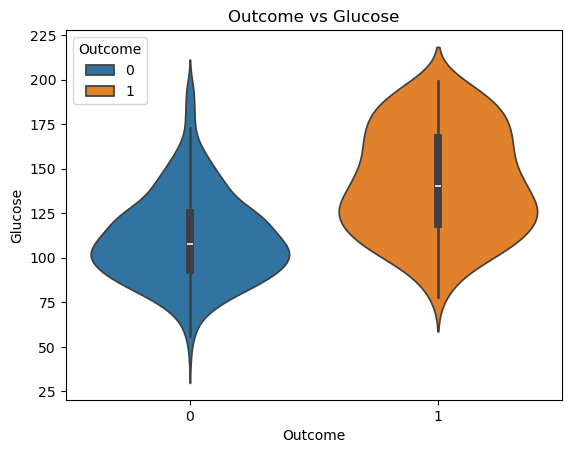

In [653]:
sns.violinplot(
    data=data,
    x='Outcome',
    y='Glucose',
    hue='Outcome'
)
plt.title("Outcome vs Glucose")
plt.show()

Looking at the violin plot, for the non-diabetic group (Outcome = 0), the fat part of the shape is lower down, centered around 100 to 110, which indicates that most non-diabetic patients have a glucose level in this lower range.

In contrast, for the diabetic group (Outcome = 1), the fat part of the shape is higher at around 130 to 140. This shows that the majority of diabetic patients have a much higher glucose level, with the median sitting right around 140.

Q30. Plot a scatter plot of Glucose vs BMI colored by Outcome — do diabetic patients cluster in a specific region of the chart?

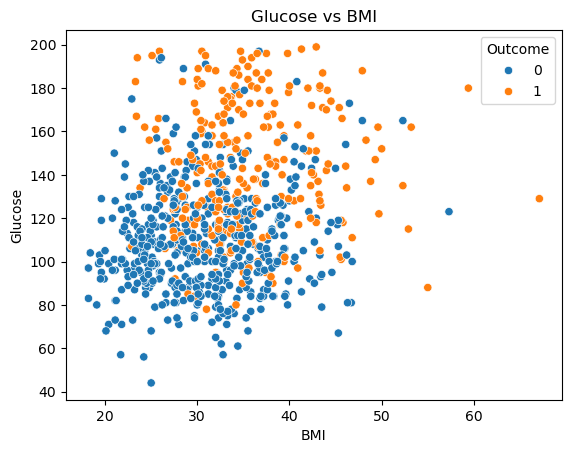

In [654]:
sns.scatterplot(
    data=data,
    x='BMI',
    y='Glucose',
    hue='Outcome'
)
plt.title("Glucose vs BMI")
plt.show()

yes, diabetic patient cluster in the upper region of the chart. from figure, it indicates that majority of diabetic patient's Glucose level is above 110.Yes, diabetic patients heavily cluster in the upper and upper-right regions of the chart.

Additionally, they tend to cluster at higher BMI values (mostly above 30), showing that patients with both higher glucose and higher BMI have a much higher likelihood of being diabetic.

Q31. Plot a bar chart showing diabetes rate percentage for each Age Group — which group is at highest risk?

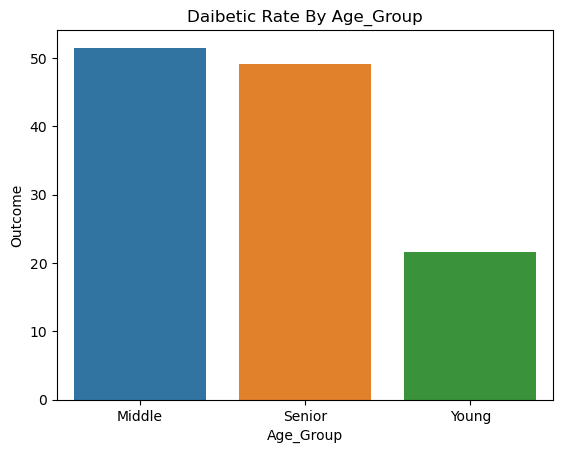

In [655]:
age_group_rate=data.groupby('Age_Group')['Outcome'].mean().reset_index()
sns.barplot(
    data=age_group_rate,
    x='Age_Group',
    y=age_group_rate['Outcome']*100,
    hue='Age_Group'
)
plt.title("Daibetic Rate By Age_Group")
plt.show()

Middle Aged group is at highest risk of diabetic.

Q32. Plot a pairplot for Glucose, BMI, Age, and Insulin colored by Outcome — which pair of features shows the cleanest separation?

<Figure size 2000x1500 with 0 Axes>

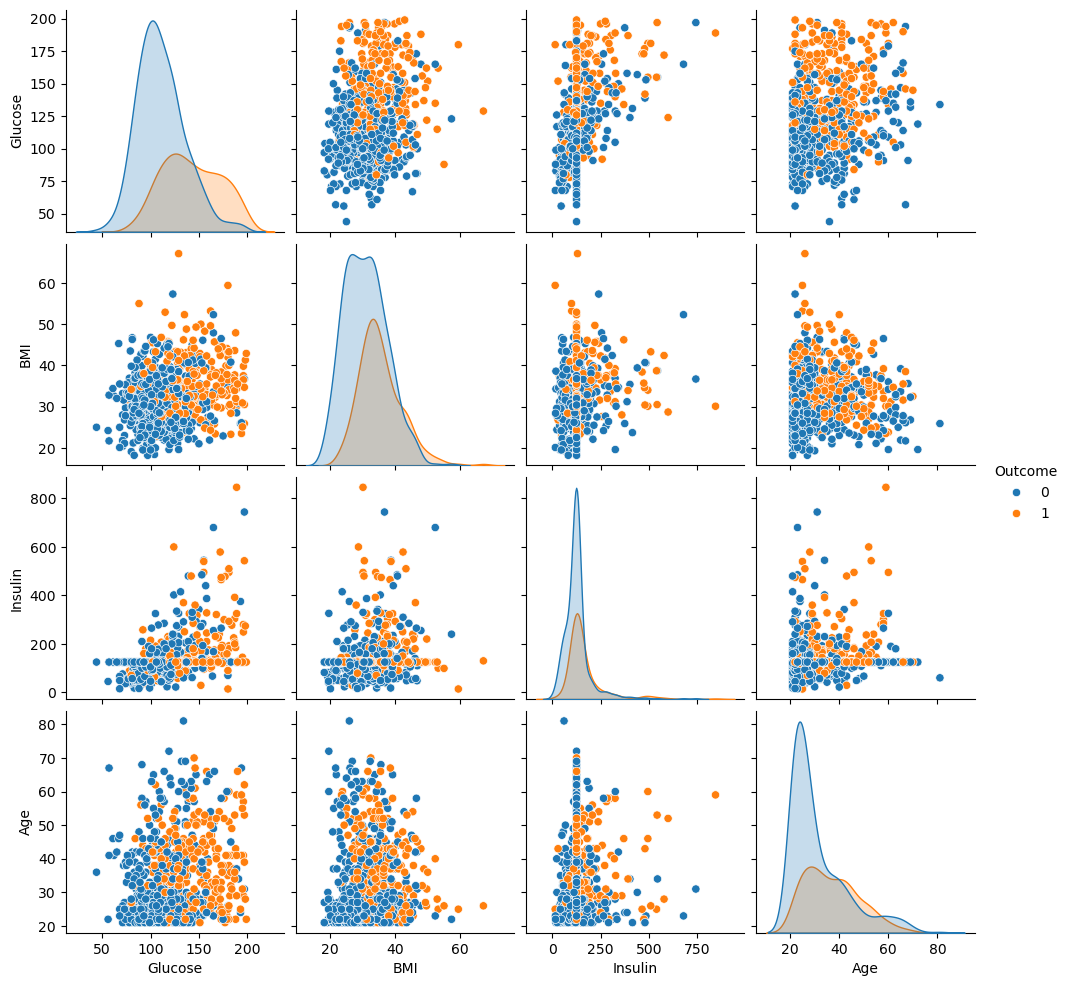

In [656]:
plt.figure(figsize=(20,15))
sns.pairplot(
    data=data,
    x_vars=["Glucose", "BMI", "Insulin","Age"],
    y_vars=["Glucose", "BMI", "Insulin","Age"],
    hue='Outcome'
)
plt.show()


Glucose feature shows the cleanest seperation. The orange dots (1) dominantly cluster toward the upper half of the y-axis (higher glucose levels), while the blue dots (0) cluster heavily at the bottom half. which indicates higher glucose level the more risk of diabetic.

Q33. Plot a bar chart of diabetes rate by BMI Category ordered from Underweight to Obese — does risk increase consistently with BMI?

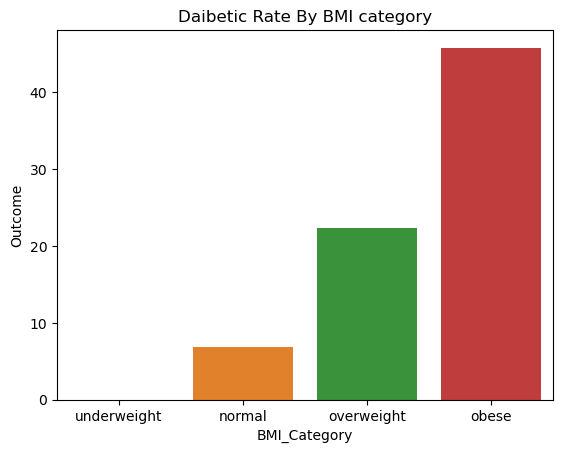

In [657]:
bmi_group_rate=data.groupby('BMI_Category')['Outcome'].mean().reset_index().sort_values(by='Outcome',ascending=True)
sns.barplot(
    data=bmi_group_rate,
    x='BMI_Category',
    y=bmi_group_rate['Outcome']*100,
    hue='BMI_Category'
)
plt.title("Daibetic Rate By BMI category")
plt.show()

yes diabetic risk consistently increase with BMI.

Q34. Plot a KDE density plot of Age for diabetic and non-diabetic patients overlaid on the same chart — is the diabetic curve shifted toward older ages?

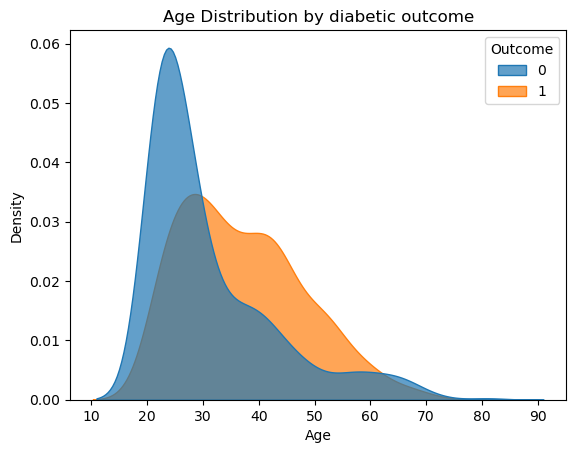

In [658]:
sns.kdeplot(
    data=data, 
    x='Age', 
    hue='Outcome', 
    fill=True, 
    common_norm=False,  # Scales each curve independently so they are comparable
    alpha=0.7
)
plt.title("Age Distribution by diabetic outcome")
plt.show()

Yes, the diabetic curve shifted toward older ages. Older Age higher risk for diabatic.

Q35. Plot a horizontal bar chart showing the correlation of each feature with Outcome?

In [659]:
data.corr(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetespedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


In [660]:
df=data.corr(numeric_only=True)['Outcome'].sort_values()
df = df.to_frame(name='Correlation').reset_index()
df

,index,Correlation
0,BloodPressure,0.165723
1,DiabetespedigreeFunction,0.173844
2,Insulin,0.203790
3,SkinThickness,0.214873
4,Pregnancies,0.221898
5,Age,0.238356
6,BMI,0.312038
7,Glucose,0.492782
8,Outcome,1.000000


<Axes: xlabel='Correlation', ylabel='index'>

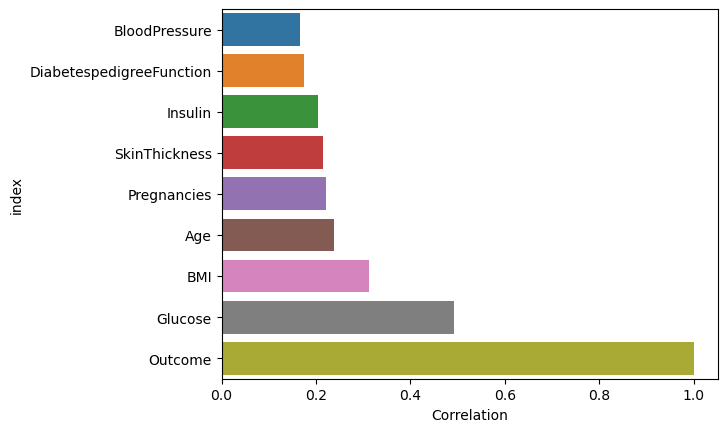

In [661]:
sns.barplot(
    data=df,
    x='Correlation',
    y='index',
    hue='index'
)

<Axes: >

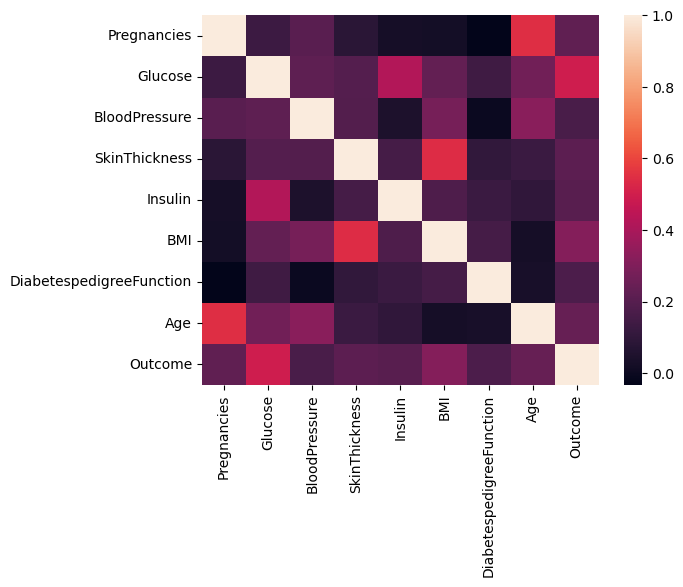

In [662]:
sns.heatmap(data.corr(numeric_only=True))

In [663]:
# to save the file in csv formate
data.to_csv('diabetic_patient.csv')